In [ ]:
import os
import os.path as op
import xarray as xr

import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from bluemath.plotting.common import load_coast
import numpy as np
p_db = op.join(os.getcwd())

### CoDEC

In [ ]:
import xarray as xr
 
ds = (
    xr.open_dataset("https://geoocean.sci.unican.es/thredds/dodsC/faggregatedCODEC.nc")
    .chunk({"time": 365 * 24})
    .load()
)
ds

In [ ]:
# Location

Location = (-8.994052,  43.246103)

lon = Location[0]
lat = Location[1]

In [ ]:
X = ds.station_x_coordinate.values
Y = ds.station_y_coordinate.values
station_id =  ds.stations.values

x_min, y_min = lon + 0.3, lat - 0.1  # lon_min; lat_min
x_max, y_max = lon - 0.3, lat + 0.1  # lon_max; lat_max

selection = (X >= x_min) & (X <= x_max) & (Y >= y_min) & (Y <= y_max)

X_selected = X[selection]
Y_selected = Y[selection]
station_sel = station_id[selection]

ERROR:fiona._env:PROJ: internal_proj_identify: /vols/abedul/software/geocean/conda/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


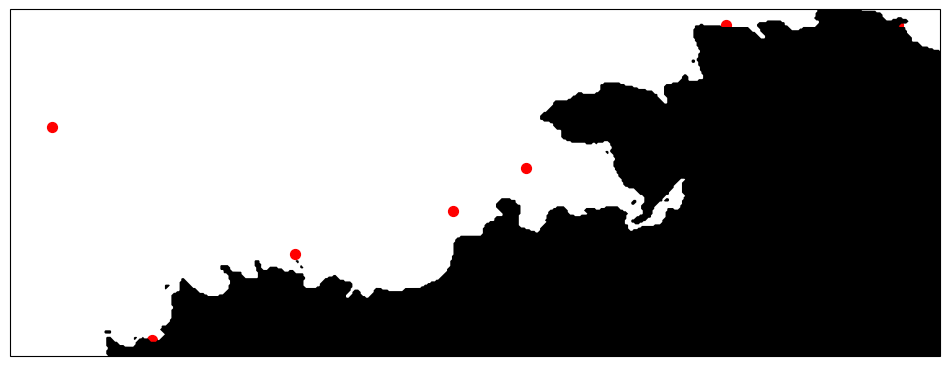

In [5]:
fig, (axs) = plt.subplots(
        nrows=1, ncols=1,figsize=[12,15], subplot_kw={'projection': ccrs.PlateCarree()},)
axs.add_feature(load_coast(), facecolor = 'black', edgecolor = None, alpha = 1, linewidth = 1.5, zorder=10)
axs.scatter(X_selected,Y_selected,c='red',s = 50)

In [6]:
# plt.scatter(X_selected,Y_selected,c='red',s = 50)

In [9]:
CODEC = ds.sel(stations = station_sel)
CODEC

<xarray.Dataset> Size: 48MB
Dimensions:               (stations: 8, time: 350640)
Coordinates:
    station_x_coordinate  (stations) float64 64B -9.192 -9.119 ... -9.243 -9.001
    station_y_coordinate  (stations) float64 64B 43.16 43.21 ... 43.27 43.25
  * stations              (stations) int16 16B 3579 3580 3581 ... 21020 21088
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time, stations) float64 22MB ...
    waterlevel            (time, stations) float64 22MB ...
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

In [ ]:
Lat = CODEC.station_y_coordinate.values
Lon = CODEC.station_x_coordinate.values
sta = CODEC.stations.values

distances = np.sqrt((Lat - Location[1])**2 + (Lon - Location[0])**2)

min_index = np.unravel_index(np.argmin(distances), distances.shape)

closest_lat = Lat[min_index]
closest_lon = Lon[min_index]
stat = sta[min_index]

ds_location = ds.sel(stations = stat)

Text(0, 0.5, 'Surge (m)')

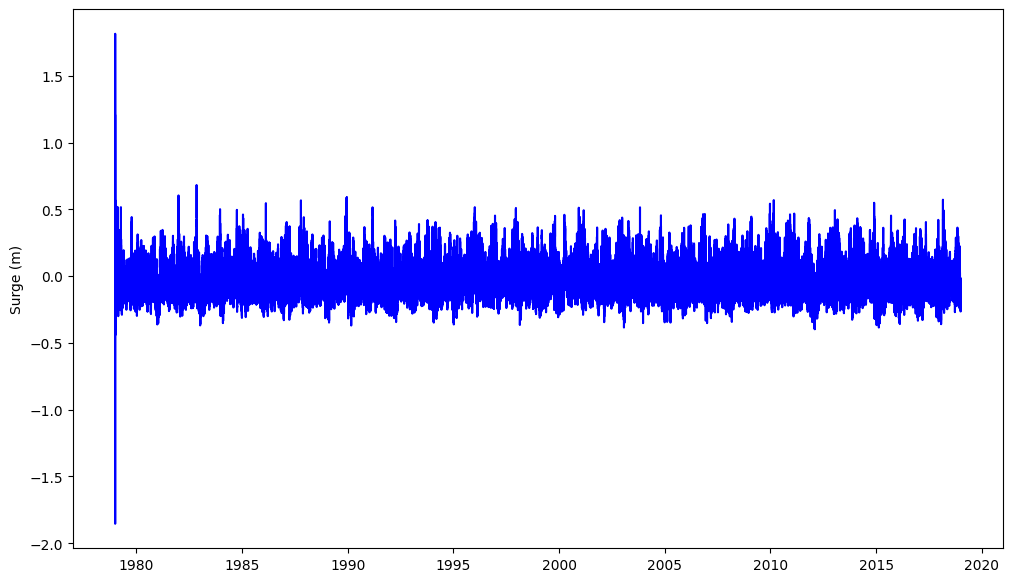

In [ ]:
fig, (axs) = plt.subplots(
        nrows=1, ncols=1,figsize=[12,7])
axs.plot(ds_location.time.values,ds_location.surge,'b')
axs.set_ylabel('Surge (m)')


In [ ]:
ds_location

<xarray.Dataset> Size: 8MB
Dimensions:               (time: 350640)
Coordinates:
    station_x_coordinate  float64 8B -9.001
    station_y_coordinate  float64 8B 43.25
    stations              int16 2B 21088
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time) float64 3MB 1.201 0.439 ... -0.156 -0.186
    waterlevel            (time) float64 3MB ...
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

In [15]:
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

import sys

import os
import os.path as op

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


import datetime
from datetime import timedelta


#### Total water level (astronomical tide + storm surge)

In [ ]:
ds_codec = ds_location
ds_codec

<xarray.Dataset> Size: 8MB
Dimensions:               (time: 350640)
Coordinates:
    station_x_coordinate  float64 8B -9.001
    station_y_coordinate  float64 8B 43.25
    stations              int16 2B 21088
  * time                  (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31...
Data variables:
    surge                 (time) float64 3MB 1.201 0.439 ... -0.156 -0.186
    waterlevel            (time) float64 3MB ...
Attributes: (12/35)
    Conventions:                   CF-1.6
    featureType:                   timeSeries
    id:                            GTSMv3_surge
    naming_authority:              https://deltares.nl/en
    Metadata_Conventions:          Unidata Dataset Discovery v1.0
    title:                         Fast Aggregated CODEC
    ...                            ...
    time_coverage_start:           2018-11-01 00:00:00
    time_coverage_end:             2018-11-30 23:00:00
    experiment:                    reanalysis
    date_modified:                 2021-05-06 19:47:58.279267 UTC
    contact:                       Please contact Copernicus User Support on ...
    history:                       Created on 2024-12-08

In [17]:
time = ds_codec.time

In [18]:
start_time = datetime.datetime(1979, 1, 1, 0, 0)  # Replace with your desired start time
twl_time = [start_time + datetime.timedelta(hours=i) for i in range(len(time))]

In [19]:
df_codec = ds_codec.to_dataframe()
df_codec

,station_x_coordinate,station_y_coordinate,stations,surge,waterlevel
time,,,,,
1979-01-01 00:00:00,-9.001,43.25,21088,1.201,0.025
1979-01-01 01:00:00,-9.001,43.25,21088,0.439,0.071
1979-01-01 02:00:00,-9.001,43.25,21088,-0.458,0.092
1979-01-01 03:00:00,-9.001,43.25,21088,-1.271,0.082
1979-01-01 04:00:00,-9.001,43.25,21088,-1.775,0.070
...,...,...,...,...,...
2018-12-31 19:00:00,-9.001,43.25,21088,-0.118,-0.544
2018-12-31 20:00:00,-9.001,43.25,21088,-0.119,-0.056
2018-12-31 21:00:00,-9.001,43.25,21088,-0.137,0.407


In [20]:
df_codec = df_codec[["surge", "waterlevel"]]
df_codec

,surge,waterlevel
time,,
1979-01-01 00:00:00,1.201,0.025
1979-01-01 01:00:00,0.439,0.071
1979-01-01 02:00:00,-0.458,0.092
1979-01-01 03:00:00,-1.271,0.082
1979-01-01 04:00:00,-1.775,0.070
...,...,...
2018-12-31 19:00:00,-0.118,-0.544
2018-12-31 20:00:00,-0.119,-0.056
2018-12-31 21:00:00,-0.137,0.407


In [ ]:
twl = df_codec[["waterlevel"]]
twl = twl.dropna()    
twl

,waterlevel
time,
1979-01-01 00:00:00,0.025
1979-01-01 01:00:00,0.071
1979-01-01 02:00:00,0.092
1979-01-01 03:00:00,0.082
1979-01-01 04:00:00,0.070
...,...
2018-12-31 19:00:00,-0.544
2018-12-31 20:00:00,-0.056
2018-12-31 21:00:00,0.407


In [23]:
# Extract the time values and data values from the DataFrame
time_values = twl.index.astype(np.int64) / (10**9)
data_values = twl['waterlevel'].to_numpy()

In [24]:
# Fit a line (linear regression) to the data
trend_line = np.poly1d(np.polyfit(time_values, data_values, 1))

In [25]:
sea_level_rise_historical = trend_line(time_values[-1])-trend_line(time_values[0])
print(sea_level_rise_historical)

0.0850166626950335


In [26]:
trend = np.empty(len(time_values), dtype=object)
for i in range(len(time_values)):
    trend[i] = trend_line(time_values[i]) - trend_line(time_values[0])

In [27]:
twl_clean = twl['waterlevel']-trend
twl_clean=pd.DataFrame(twl_clean)
twl_clean

,waterlevel
time,
1979-01-01 00:00:00,0.025
1979-01-01 01:00:00,0.071
1979-01-01 02:00:00,0.092
1979-01-01 03:00:00,0.081999
1979-01-01 04:00:00,0.069999
...,...
2018-12-31 19:00:00,-0.629016
2018-12-31 20:00:00,-0.141016
2018-12-31 21:00:00,0.321984


## Non-tidal residual

In [28]:
# CODEC

In [29]:
ssr = df_codec[["surge"]]
ssr

,surge
time,
1979-01-01 00:00:00,1.201
1979-01-01 01:00:00,0.439
1979-01-01 02:00:00,-0.458
1979-01-01 03:00:00,-1.271
1979-01-01 04:00:00,-1.775
...,...
2018-12-31 19:00:00,-0.118
2018-12-31 20:00:00,-0.119
2018-12-31 21:00:00,-0.137


In [30]:
start_time = datetime.datetime(1979, 1, 1, 0, 0)  # Replace with your desired start time
ssr_time = [start_time + datetime.timedelta(hours=i) for i in range(len(ssr.surge.values))]

In [31]:
ssr = ssr.dropna()

#### Common time period of the total water level and storm surge

In [32]:
twl_ssr = pd.merge(twl_clean, ssr, left_index=True, right_index=True, how='inner')

In [33]:
twl_ssr

,waterlevel,surge
time,,
1979-01-01 00:00:00,0.025,1.201
1979-01-01 01:00:00,0.071,0.439
1979-01-01 02:00:00,0.092,-0.458
1979-01-01 03:00:00,0.081999,-1.271
1979-01-01 04:00:00,0.069999,-1.775
...,...,...
2018-12-31 19:00:00,-0.629016,-0.118
2018-12-31 20:00:00,-0.141016,-0.119
2018-12-31 21:00:00,0.321984,-0.137


#### Astronomical tide (Total water level - non-tidal residual)

In [34]:
AT = twl_ssr['waterlevel'] - twl_ssr['surge']
AT = AT.rename('AT', inplace=True)

In [35]:
len(AT)

350393

#### Non-tidal residual filtrada (average mean)

In [ ]:
# Calculate average mean with a window of 3 days
ventana = 12
media_movil = twl_ssr['surge'].rolling(window=ventana).mean()

In [37]:
len(media_movil)

350393

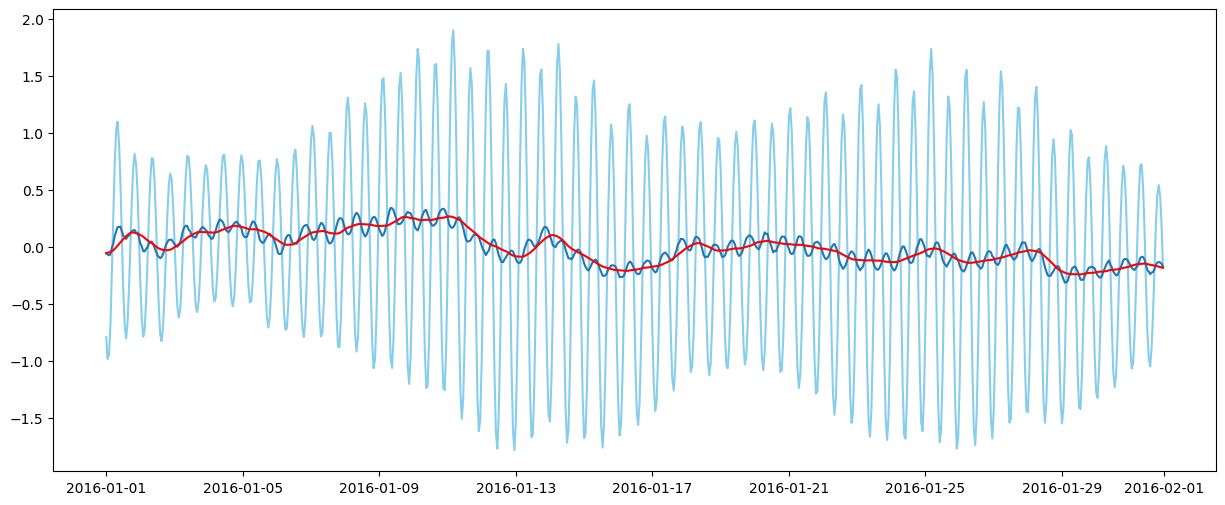

In [38]:
year_to_filter = 2016
month_to_filter = 1
twl_ssr_f = twl_ssr[(twl_ssr.index.year == year_to_filter) & (twl_ssr.index.month == month_to_filter)]
fig, ax = plt.subplots(figsize=(15,6))
ax.plot(twl_ssr_f.index, twl_ssr_f['waterlevel'], label='Storm Surge + Astronomical tide - Sea Level Rise',color='skyblue')
ax.plot(twl_ssr_f.index, twl_ssr_f['surge'])
ax.plot(twl_ssr_f.index, media_movil[(twl_ssr.index.year == year_to_filter) & (twl_ssr.index.month == month_to_filter)],color='red')

In [39]:
media_movil.values 

array([        nan,         nan,         nan, ..., -0.18508333,
       -0.18225   , -0.17883333], shape=(350393,))

In [40]:
twl_ssr['surge_rolling_mean'] = media_movil.values 
twl_ssr

,waterlevel,surge,surge_rolling_mean
time,,,
1979-01-01 00:00:00,0.025,1.201,NaN
1979-01-01 01:00:00,0.071,0.439,NaN
1979-01-01 02:00:00,0.092,-0.458,NaN
1979-01-01 03:00:00,0.081999,-1.271,NaN
1979-01-01 04:00:00,0.069999,-1.775,NaN
...,...,...,...
2018-12-31 19:00:00,-0.629016,-0.118,-0.185000
2018-12-31 20:00:00,-0.141016,-0.119,-0.185500
2018-12-31 21:00:00,0.321984,-0.137,-0.185083


In [ ]:
# Differente between consecutive times
time_diffs = twl_ssr.index.to_series().diff()

# Filter where there is a jump greater than the minimum expected
saltos = time_diffs[time_diffs > time_diffs.min()]

# Show the dates where we have jumps
print("Fechas con saltos en la serie:")
print(saltos.index)

Fechas con saltos en la serie:
DatetimeIndex(['1979-01-15 10:00:00', '1979-05-20 17:00:00',
               '1979-06-30 13:00:00', '1979-07-28 11:00:00',
               '1979-08-19 08:00:00', '1979-08-29 13:00:00',
               '1980-01-27 19:00:00', '1980-03-07 12:00:00',
               '1980-07-08 18:00:00', '1980-10-05 19:00:00',
               ...
               '2017-07-15 15:00:00', '2017-08-25 23:00:00',
               '2017-10-12 15:00:00', '2017-11-01 07:00:00',
               '2017-12-17 08:00:00', '2018-04-12 08:00:00',
               '2018-06-23 06:00:00', '2018-10-11 22:00:00',
               '2018-11-08 21:00:00', '2018-11-12 01:00:00'],
              dtype='datetime64[ns]', name='time', length=247, freq=None)


In [42]:
len(saltos)

247

In [ ]:
# Create a new index with regular frequency
time_range = pd.date_range(start=twl_ssr.index.min(), end=twl_ssr.index.max(), freq="H")  # Ajusta la frecuencia según tus datos

# Reindex to add missing dates
twl_ssr = twl_ssr.reindex(time_range)

# Interpolate missing values
twl_ssr = twl_ssr.interpolate(method="time")
twl_ssr

/tmp/ipykernel_2146276/2429385712.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(start=twl_ssr.index.min(), end=twl_ssr.index.max(), freq="H")  # Ajusta la frecuencia según tus datos
/tmp/ipykernel_2146276/2429385712.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  twl_ssr = twl_ssr.interpolate(method="time")


,waterlevel,surge,surge_rolling_mean
1979-01-01 00:00:00,0.025,1.201,NaN
1979-01-01 01:00:00,0.071,0.439,NaN
1979-01-01 02:00:00,0.092,-0.458,NaN
1979-01-01 03:00:00,0.081999,-1.271,NaN
1979-01-01 04:00:00,0.069999,-1.775,NaN
...,...,...,...
2018-12-31 19:00:00,-0.629016,-0.118,-0.185000
2018-12-31 20:00:00,-0.141016,-0.119,-0.185500
2018-12-31 21:00:00,0.321984,-0.137,-0.185083
2018-12-31 22:00:00,0.661984,-0.156,-0.182250


In [ ]:
# Calculate the difference between consecutive times
time_diffs = twl_ssr.index.to_series().diff()

# Filter where there is a jump greater than the minimum expected
saltos = time_diffs[time_diffs > time_diffs.min()]

# Show the dates where we have jumps
print("Fechas con saltos en la serie:")
print(saltos.index)


Fechas con saltos en la serie:
DatetimeIndex([], dtype='datetime64[ns]', freq='h')


In [45]:
twl_ssr

,waterlevel,surge,surge_rolling_mean
1979-01-01 00:00:00,0.025,1.201,NaN
1979-01-01 01:00:00,0.071,0.439,NaN
1979-01-01 02:00:00,0.092,-0.458,NaN
1979-01-01 03:00:00,0.081999,-1.271,NaN
1979-01-01 04:00:00,0.069999,-1.775,NaN
...,...,...,...
2018-12-31 19:00:00,-0.629016,-0.118,-0.185000
2018-12-31 20:00:00,-0.141016,-0.119,-0.185500
2018-12-31 21:00:00,0.321984,-0.137,-0.185083
2018-12-31 22:00:00,0.661984,-0.156,-0.182250


In [46]:
ds_twl_ssr = twl_ssr.to_xarray()
ds_twl_ssr

<xarray.Dataset> Size: 11MB
Dimensions:             (index: 350640)
Coordinates:
  * index               (index) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31T...
Data variables:
    waterlevel          (index) object 3MB 0.025 0.071 0.092 ... 0.662 0.778
    surge               (index) float64 3MB 1.201 0.439 -0.458 ... -0.156 -0.186
    surge_rolling_mean  (index) float64 3MB nan nan nan ... -0.1822 -0.1788

In [47]:
ds_twl_ssr = ds_twl_ssr.rename_dims({"index": "time"})
ds_twl_ssr = ds_twl_ssr.rename({"index": "time"})

/tmp/ipykernel_2146276/1057451519.py:2: UserWarning: rename 'index' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_twl_ssr = ds_twl_ssr.rename({"index": "time"})


In [48]:
ds_twl_ssr

<xarray.Dataset> Size: 11MB
Dimensions:             (time: 350640)
Coordinates:
  * time                (time) datetime64[ns] 3MB 1979-01-01 ... 2018-12-31T2...
Data variables:
    waterlevel          (time) object 3MB 0.025 0.071 0.092 ... 0.662 0.778
    surge               (time) float64 3MB 1.201 0.439 -0.458 ... -0.156 -0.186
    surge_rolling_mean  (time) float64 3MB nan nan nan ... -0.1822 -0.1788

In [50]:
ds_twl_ssr = ds_twl_ssr.resample(time="1D").mean()


In [49]:
ds_twl_ssr.to_netcdf('ds_ss_Ponteceso_codec_rolling_mean.nc')